**Exercise: Build decision tree model to predict survival based on certain parameters**

Titanic dataset

##### In this file using following columns build a model to predict if person would survive or not,

1. Pclass
1. Sex
1. Age
1. Fare

##### Calculate score of your model

In [2]:
import pandas as pd
data=pd.read_csv("/content/titanic.csv")

df=pd.DataFrame(data)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [14]:
x=df.drop(['PassengerId','Survived','Name','SibSp','Parch','Ticket','Cabin','Embarked'],axis='columns')
y=df['Survived']
x

,Pclass,Sex,Age,Fare
0,3,male,22.0,7.2500
1,1,female,38.0,71.2833
2,3,female,26.0,7.9250
3,1,female,35.0,53.1000
4,3,male,35.0,8.0500
...,...,...,...,...
886,2,male,27.0,13.0000
887,1,female,19.0,30.0000
888,3,female,NaN,23.4500
889,1,male,26.0,30.0000


In [16]:
from sklearn.preprocessing import LabelEncoder
le_pclass=LabelEncoder()
le_sex=LabelEncoder()
le_age=LabelEncoder()
le_fare=LabelEncoder()
x['pclass_n']=le_pclass.fit_transform(x['Pclass'])
x['sex_n']=le_sex.fit_transform(x['Sex'])
x['age_n']=le_age.fit_transform(x['Age'])
x['fare_n']=le_fare.fit_transform(x['Fare'])
x


,Pclass,Sex,Age,Fare,pclass_n,sex_n,age_n,fare_n
0,3,male,22.0,7.2500,2,1,28,18
1,1,female,38.0,71.2833,0,0,51,207
2,3,female,26.0,7.9250,2,0,34,41
3,1,female,35.0,53.1000,0,0,47,189
4,3,male,35.0,8.0500,2,1,47,43
...,...,...,...,...,...,...,...,...
886,2,male,27.0,13.0000,1,1,35,85
887,1,female,19.0,30.0000,0,0,24,153
888,3,female,NaN,23.4500,2,0,88,131
889,1,male,26.0,30.0000,0,1,34,153


In [20]:
x=x.drop(['Pclass','Sex','Age','Fare'],axis='columns')
x

,pclass_n,sex_n,age_n,fare_n
0,2,1,28,18
1,0,0,51,207
2,2,0,34,41
3,0,0,47,189
4,2,1,47,43
...,...,...,...,...
886,1,1,35,85
887,0,0,24,153
888,2,0,88,131
889,0,1,34,153


In [21]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [42]:
model.fit(x_train,y_train)

DecisionTreeClassifier()

In [48]:
y_pred=model.predict(x_test)

In [60]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.7821229050279329

In [56]:
sample=x.sample(5)

In [58]:
model.predict(sample)

array([1, 0, 0, 0, 0])

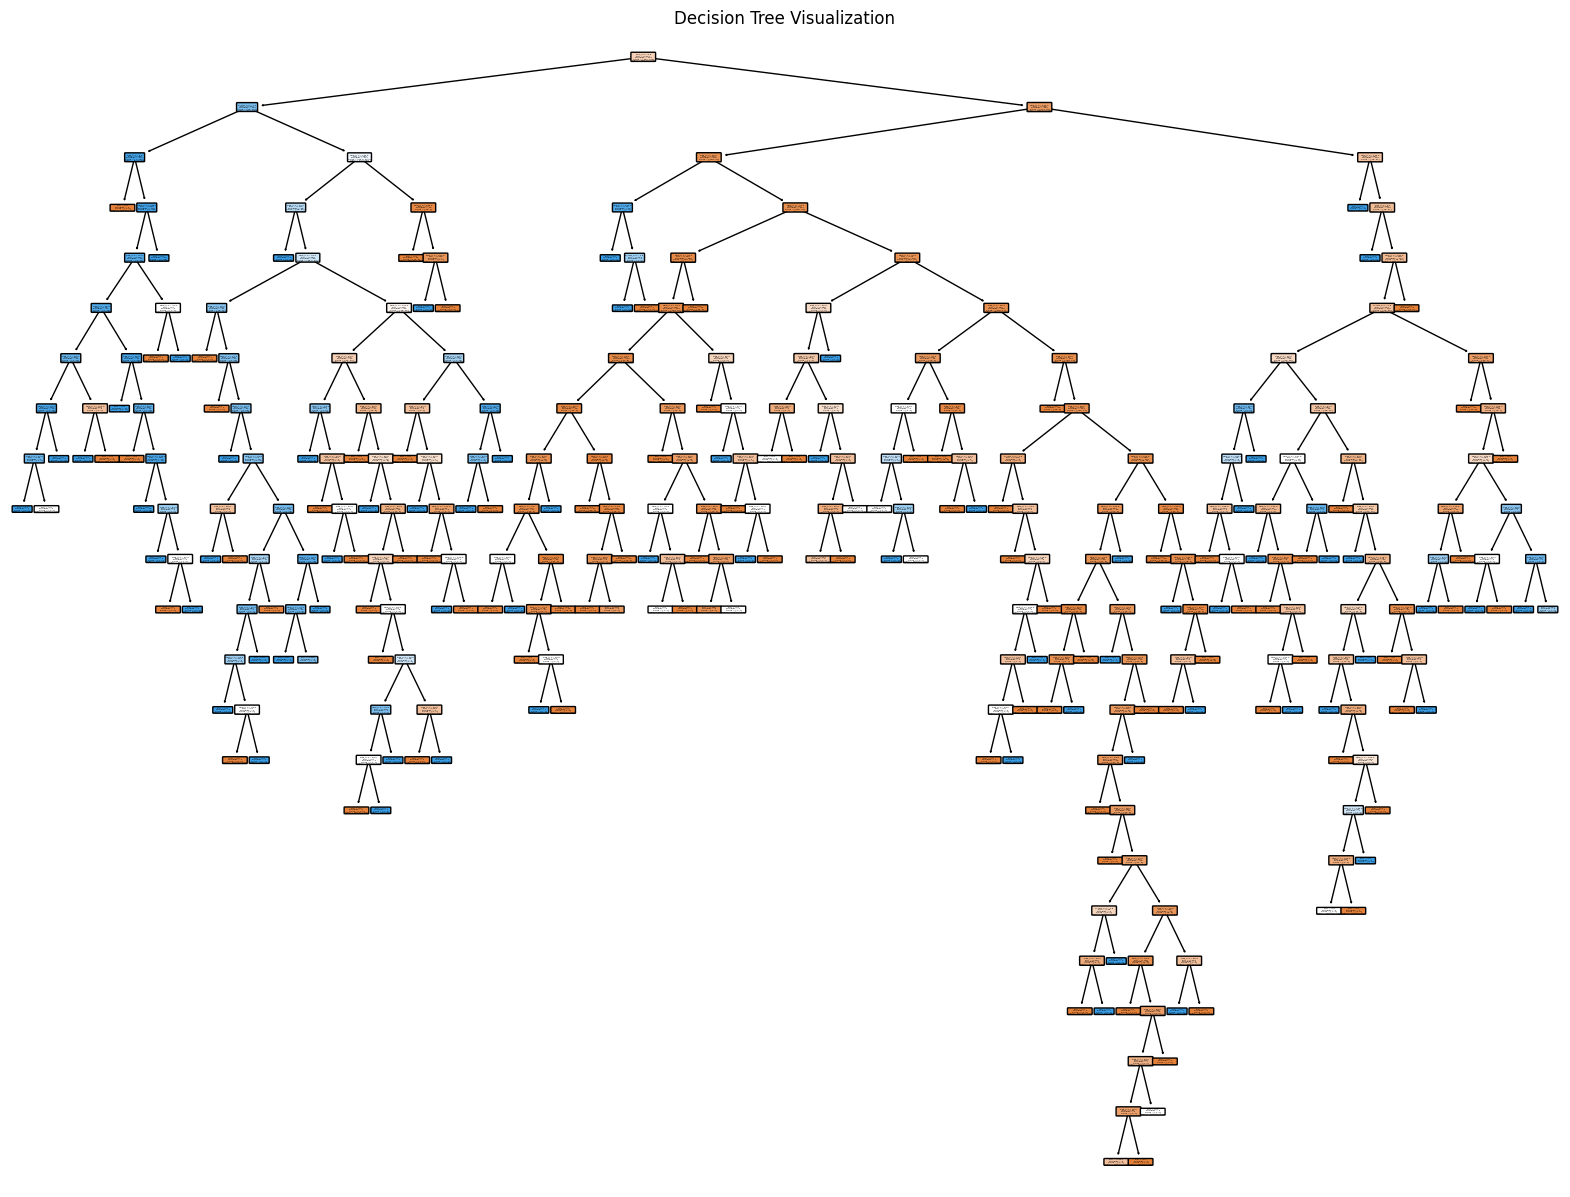

In [61]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,15))
plot_tree(model,
          feature_names=['pclass_n', 'sex_n', 'age_n', 'fare_n'],
          class_names=['Not Survived', 'Survived'],
          filled=True,
          rounded=True)
plt.title("Decision Tree Visualization")
plt.show()